# Physical baseline model — what a house should use, and who fixes the gap

**What it answers:** how much more electricity a heat-pump house uses than a
**code-compliant version of itself**, split into the three things someone can act on:

| group | what it is | owner |
|---|---|---|
| **house** | envelope + emitters + hot-water cylinder | a builder |
| **heat pump** | the unit's generation, with a replace / keep call | an installer |
| **total** | house + heat pump — **the rank** | — |

**The rule behind everything:** no constant is ever fitted to the meter. The physics is
computed first; the meter is only used to *check* it afterwards.

**Building side only.** The meter-based heating slope and any fault probability live in
a separate end section. Nothing here loads another model.

```
protocols.csv ──► p_adapter_heapo ──► roles ──► p_physics ──► E_as_built / E_reference
      │                                   ▲                        │
      │        constants_ch.json (sourced, │status per value)       │
      │                                    │                       ▼
      └───────── station normal-year weather ──────►  house / heat pump / total
                                                            │
                                              physical_baseline_v2 ──► dashboard
```

In [1]:
%matplotlib inline
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import p_physics as ph
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3})
OUTS = Path("outputs")
FIG = OUTS / "deliverable" / "figures"
ERA = ["pre1975", "1976_1990", "1991_2000", "2001_2010", "post2010"]

def load(rel):
    p = OUTS / rel
    if not p.exists():
        print("missing, run the stage first:", rel)
        return None
    return pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p, sep=";")

E = load("export/physical_baseline_v2.parquet")
print("export:", None if E is None else E.shape)

export: (214, 66)


## 0. Inputs and population

Three inputs, all read-only: the audit protocols, the daily meter states, and the
household weather. 410 protocol reports; 217 carry a household ID; 214 distinct
households once the three repeat visits collapse to the first.

In [2]:
from p_adapter_heapo import load_households, modellable
H = load_households("../heapo_data/reports/protocols.csv")
funnel = pd.DataFrame({
    "stage": ["protocol reports", "reports carrying a Household_ID",
              "distinct households", "modellable - every required role present",
              "assessed - enough meter days as well"],
    "n": [410, 217, len(H), int(modellable(H).sum()),
          int((E.phys_status != "INCOMPLETE_AUDIT").sum()) if E is not None else None]})
display(funnel)

,stage,n
0,protocol reports,410
1,reports carrying a Household_ID,217
2,distinct households,214
3,modellable - every required role present,190
4,assessed - enough meter days as well,172


## Where the constants come from — and what is still unverified

Every constant lives in `constants_ch.json` with a **status**. The registry is
regenerated by `p22_registry.py`, and a test re-derives the U-values from their
published inputs, so the file cannot drift from its sources.

The spec this project started from cited documents that **do not contain the values**:
Switzerland is not a TABULA/EPISCOPE country, and the cited heat-pump table was a list
of measured systems. Replacements were found through the project's verified-source
notebook and read in the primary PDFs (P19–P22).

In [3]:
rows = [(k, v[0], v[4][:46], ph.STATUS[k]) for k, v in sorted(ph.C.items())]
S = pd.DataFrame(rows, columns=["constant", "value", "source (truncated)", "status"])
display(S)
print(dict(S.status.value_counts()))
inp = ph._REG.get("inputs", {})
print("registry inputs:", {k: v.get("status") for k, v in inp.items()})

,constant,value,source (truncated),status
0,appl_efh_4p,4048.0000,BFE/EnergieSchweiz Faktenblatt 08.2021; hi S.A,VERIFIED
1,appl_efh_per_person,593.5000,BFE/EnergieSchweiz Faktenblatt 08.2021; hi S.A,VERIFIED
2,appl_taper_5plus,50.0000,BFE/EnergieSchweiz Faktenblatt 08.2021,VERIFIED
3,b_ground,0.5000,"Hoffmann & Geissler, FHNW, Energy Procedia 122",VERIFIED
4,dhw_kwh_person_day,2.6100,"FAWA 2004 Table 3 p.44 (3,811 kWh/yr, 4-person",VERIFIED
5,du_thermal_bridge,0.1000,TABULA Common Calculation Method (IEE TABULA),VERIFIED
6,hp_service_life_air,20.0000,"Hubbuch & Vecsei, ZHAW Institut fuer Facility",VERIFIED
7,hp_service_life_ground,26.7000,"Hubbuch & Vecsei, ZHAW Institut fuer Facility",VERIFIED
8,jaz_ashp_floor,3.7000,OST WPZ Buchs P+I 11/12-2020 Tabelle 1; RISE I,VERIFIED
9,jaz_ashp_lowrad,3.3000,OST WPZ Buchs P+I 11/12-2020 Tabelle 1; RISE I,VERIFIED


{'VERIFIED': np.int64(19), 'DERIVED': np.int64(12), 'PHYSICAL': np.int64(1), 'SECOND_HAND': np.int64(1)}
registry inputs: {'tep2016_efh': 'VERIFIED', 'pre1975_stock_share': 'VERIFIED', 'muken': 'VERIFIED', 'area_split': 'VERIFIED'}


## P0 — which degree-day definition

The spec asked for SIA 20/12 degree-days; the project standard is `HDD_12`. They are
not rescalings of each other: **`HDD_SIA = HDD_12 + 8 · 1{T < 12}`**, exact on all
878,128 usable days, so SIA welds a step of 8 into the slope.

**Decision: `HDD_12`.** The fit is a dead heat fleet-wide. The deciding reason is
structural: this model computes its baseload and fits nothing, so it has no free
intercept to absorb SIA's hidden step.

In [4]:
r = load("p0/data/p0_hdd_fits_cohort_all.csv")
if r is not None:
    display(pd.DataFrame({"definition": ["HDD_12", "HDD_SIA"],
                          "median R²": [r.r2_12.median().round(4), r.r2_sia.median().round(4)],
                          "households": [len(r), len(r)]}))

,definition,median R²,households
0,HDD_12,0.7299,193
1,HDD_SIA,0.7226,193


## P1 — is the heat pump the right size for the building?

Required capacity from SIA 384.201 design loads against installed capacity, scored
against the inspector's *correctly planned* verdict — used only to score, never as an
input. **Oversizing is detectable: AUC 0.772**, and it replicated at 0.786 when
required capacity came from this model's own physics.

In [5]:
v = load("p1/data/p1_sizing_validation.csv")
if v is not None:
    g = v.groupby(v.cat.fillna("correctly planned")).ratio_renov_adj.agg(["count", "median"])
    display(g.round(2).rename(columns={"count": "n", "median": "median sizing ratio"}))

,n,median sizing ratio
cat,,
correctly planned,174,1.28
oversized,18,1.78
undersized,6,0.85


## P18 / P22 — weather: the station's normal year

Category B never reads consumption, yet its degree-days used to come from the
household's own meter days, which tied a building score to how long the meter ran. Each
household now takes its **station's normal-year HDD_12** (complete years only), so
**record length no longer enters the building score at all** — asserted on every run.

An earlier correction by record-length bins turned out to over-correct this cohort:
records under a year read *warm*, not cold, and the bins deflated them by up to a third.

## P21 / P22 — the sourced constants, and what they changed

The U-values now come from **TEP Energy's Swiss building-stock model** (BFE
Schlussbericht 2016, single-family houses) weighted by a **Swiss reference envelope
split** (TEP/INSPIRE 2015, Table 15), with the legal MuKEn limits for post-2010 and for
the code-compliant reference. Heating efficiency comes from the **OST field table**
(P+I 11/12-2020), reproduced by a **RISE** conference paper.

Pre-1975 envelope: **0.90** against the old 1.35, whose band did not even overlap. Four
independent checks improved at once, while the *level* moved away from 1.0 — so this is
not a fit.

In [6]:
U = pd.DataFrame([(e, ph.value(ph.ERA_KEYS[e])) + ph.band(ph.ERA_KEYS[e])
                  for e in ERA], columns=["era", "U", "lo", "hi"])
U["reference (MuKEn 2014)"] = ph.value("u_reference")
display(U.round(3))

,era,U,lo,hi,reference (MuKEn 2014)
0,pre1975,0.903,0.824,0.982,0.247
1,1976_1990,0.709,0.630,0.788,0.247
2,1991_2000,0.364,0.322,0.405,0.247
3,2001_2010,0.364,0.322,0.405,0.247
4,post2010,0.269,0.247,0.291,0.247


## P23 / P24 — the heat pump: vintage, then a recommendation

Field studies show a 1999 unit delivers ~0.79 (air) / 0.76 (ground) of a 2017 unit, and
**no loss from use** over 9 operating years — so this is technology generation, not wear.
The reference house always gets a current unit, so an older unit becomes its own term.

**The meter confirms it, and it is not heating-curve settings in disguise:** measured ÷
physics runs 1.47 for pre-2008 units, 1.05 for 2015+, and the gradient survives inside
equal curve settings (age +2.1%/yr [0.9, 3.4], unchanged when the curve enters).

"Old" is not an action, so each unit carries a **recommendation** against its sourced
service life (ZHAW: air 20 yr, ground 26.7 yr; ages as of the **data end, 2024**).

In [7]:
M = load("p23/data/p23_meter_check.parquet")
R = load("p24/data/p24_unit_recommendation.parquet")
if M is not None:
    g = ["<2008", "2008-2014", ">=2015", "unknown"]
    t = pd.DataFrame({"vintage OFF": (M.beta_meas / M.bp_off).groupby(M.grp).median(),
                      "vintage ON": (M.beta_meas / M.bp_on).groupby(M.grp).median(),
                      "n": M.groupby("grp").size()}).reindex(g)
    display(t.round(2))
if R is not None:
    display(R.unit_recommendation.value_counts().rename("households").to_frame())

,vintage OFF,vintage ON,n
grp,,,
<2008,1.47,1.28,20
2008-2014,1.22,1.15,30
>=2015,1.05,1.03,42
unknown,1.30,1.30,53


,households
unit_recommendation,
KEEP_IN_LIFE,87
RECORD_INSTALL_YEAR,85
PLAN_REPLACEMENT,30
REPLACE_END_OF_LIFE,12


## P10 — does the method travel?

The physics layer knows nothing about HEAPO: it takes variable **roles**, and one
adapter maps each dataset onto them. Three adapters ran with the physics untouched. The
third, on `meta_data.csv`, **correctly refuses** — it lacks construction era and
per-storey geometry, and says so before computing anything.

In [8]:
mc = load("p10/data/p10_meta_contract.csv")
if mc is not None:
    display(mc[["role", "n_present", "status", "why_missing"]])

,role,n_present,status,why_missing
0,area_m2,1339,OK,NaN
1,footprint_m2,0,MISSING,no per-storey areas - only one whole-dwelling ...
2,n_storeys_above,0,MISSING,no storey information of any kind
3,heated_basement,0,MISSING,no basement information of any kind
4,era,0,MISSING,no construction or installation year exists in...
5,renovation_count,0,MISSING,no renovation flags
6,residents,1348,OK,NaN
7,hp_type,1354,OK,NaN
8,emitter,1310,OK,NaN
9,dhw_electric,1358,OK,NaN


## P11 v2 — the building score, and the one fleet-wide list

Four states, and **none of them says normal** — that would need a household's whole band
at or below code, and not one is. So the model confirms an excess, never its absence.

| state | meaning |
|---|---|
| `HIGH_EXCESS` | confirmed excess, worst 25% **of the fleet** |
| `EXCESS_CONFIRMED` | confirmed excess, below that cut |
| `INCONCLUSIVE` | computed, band straddles zero — **no claim** |
| `INCOMPLETE_AUDIT` | not computed, building data missing — **fixable** |

**Ranked fleet-wide on the lower bound** (Miguel 2026-09-12), with era as a filter and
`phys_rank_in_era` kept. Declared with it: per m² the physics under-predicts newer eras
by 24–53%, so this order tilts toward older houses.

**Option A:** a unit's vintage counts in the total but **not** in the ranking value for
units we would keep — a 10-year-old unit must not push a near-compliant house onto the
act list.

,households
phys_status,
EXCESS_CONFIRMED,118
INCOMPLETE_AUDIT,42
HIGH_EXCESS,40
INCONCLUSIVE,14


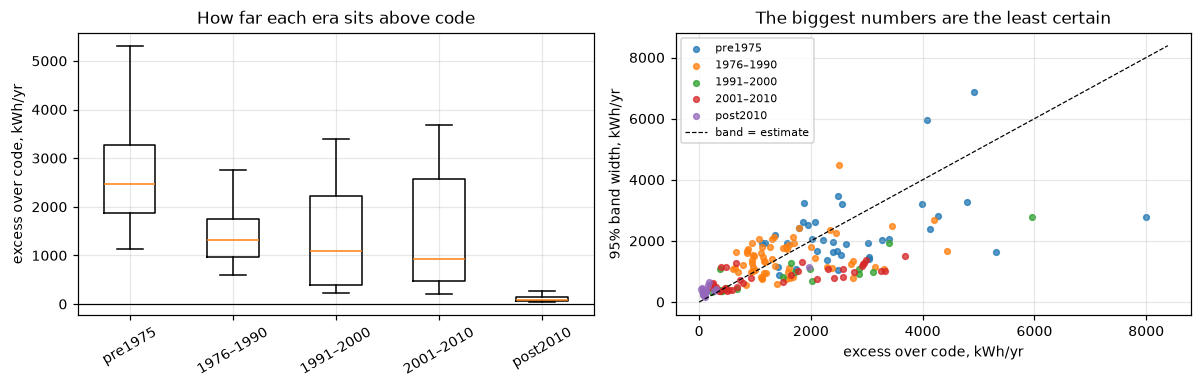

In [9]:
if E is not None:
    display(E.phys_status.value_counts().rename("households").to_frame())
    s = E.dropna(subset=["phys_deficiency_kwh_yr"])
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    ax[0].boxplot([s[s.phys_era == e].phys_deficiency_kwh_yr for e in ERA],
                  tick_labels=[e.replace("_", "–") for e in ERA], showfliers=False)
    ax[0].axhline(0, color="k", lw=.8)
    ax[0].set_ylabel("excess over code, kWh/yr")
    ax[0].set_title("How far each era sits above code")
    ax[0].tick_params(axis="x", rotation=30)
    for e in ERA:
        q = s[s.phys_era == e]
        ax[1].scatter(q.phys_deficiency_kwh_yr, q.phys_deficiency_band_kwh_yr, s=14,
                      alpha=.75, label=e.replace("_", "–"))
    lim = [0, s.phys_deficiency_kwh_yr.max() * 1.05]
    ax[1].plot(lim, lim, "k--", lw=.8, label="band = estimate")
    ax[1].set_xlabel("excess over code, kWh/yr")
    ax[1].set_ylabel("95% band width, kWh/yr")
    ax[1].set_title("The biggest numbers are the least certain")
    ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.savefig(FIG / "D01_by_era.png", dpi=130)

### The list itself — three columns, never one number

Top of the single fleet-wide list, on the lower bound. **house** is a builder's job,
**heat pump** an installer's. They are shown side by side, and the capacity scenario is
never added to either.

,house,era,house kWh/yr (at least),heat pump kWh/yr (at least),unit,rank value
0,116121,pre1975,6787.0,286.0,PLAN_REPLACEMENT,7142.0
1,876511,1991_2000,5308.0,13.0,RECORD_INSTALL_YEAR,5610.0
2,1111201,pre1975,4850.0,71.0,KEEP_IN_LIFE,4850.0
3,5011111,pre1975,4617.0,13.0,RECORD_INSTALL_YEAR,4632.0
4,1137376,1976_1990,4145.0,7.0,RECORD_INSTALL_YEAR,4269.0
5,700831,1976_1990,3855.0,28.0,RECORD_INSTALL_YEAR,3984.0
6,105900,2001_2010,3265.0,20.0,RECORD_INSTALL_YEAR,3463.0
7,698983,pre1975,3122.0,0.0,KEEP_IN_LIFE,3122.0
8,7610179,1991_2000,2834.0,27.0,RECORD_INSTALL_YEAR,3062.0
9,671781,pre1975,2705.0,201.0,REPLACE_END_OF_LIFE,2986.0


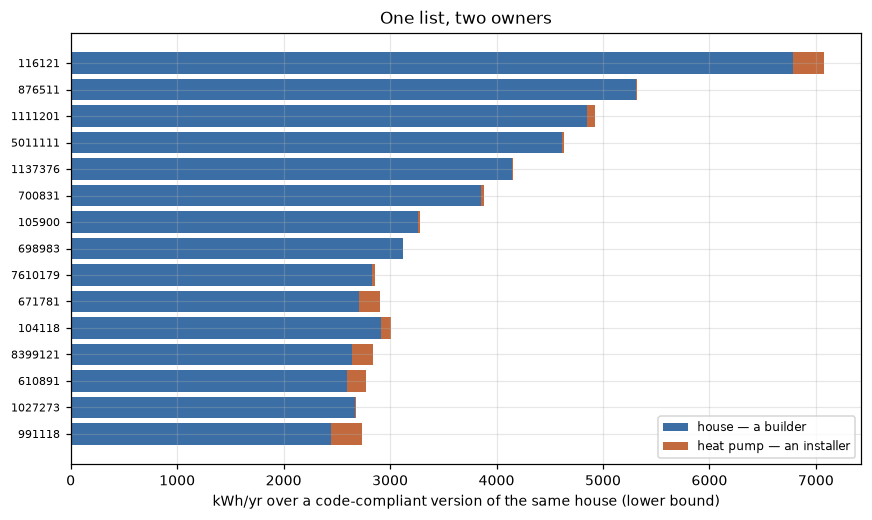

In [10]:
if E is not None:
    top = E[E.phys_status.isin(["HIGH_EXCESS", "EXCESS_CONFIRMED"])].nsmallest(15, "phys_rank_fleet")
    show = pd.DataFrame({
        "house": top.household_id.values, "era": top.phys_era.values,
        "house kWh/yr (at least)": top.phys_group_house_lo_kwh_yr.values,
        "heat pump kWh/yr (at least)": top.phys_group_heat_pump_lo_kwh_yr.values,
        "unit": top.phys_unit_recommendation.values,
        "rank value": top.phys_rank_value_lo_kwh_yr.values})
    display(show)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    y = np.arange(len(top))[::-1]
    ax.barh(y, top.phys_group_house_lo_kwh_yr, color="#3b6ea5", label="house — a builder")
    ax.barh(y, top.phys_group_heat_pump_lo_kwh_yr, left=top.phys_group_house_lo_kwh_yr,
            color="#c26a3d", label="heat pump — an installer")
    ax.set_yticks(y); ax.set_yticklabels(top.household_id, fontsize=7)
    ax.set_xlabel("kWh/yr over a code-compliant version of the same house (lower bound)")
    ax.set_title("One list, two owners")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(FIG / "D02_three_groups.png", dpi=130)

## P13 v2 — the visit axis, kept out of these pages

The meter-based axis still exists in the export for the **end section**, where the two
models meet. It is computed on **post-visit days only**, with the heating-season step
fitted free, and a status taken from a 95% band rather than a point estimate.

Most of the old "~22% slope baseline" was a fitting artefact: a straight line through
the step absorbed it as slope. With the step free, physics predicts the fleet heating
slope to within a few per cent — with nothing tuned.

| state | meaning |
|---|---|
| `SLOPE_EXCESS` | whole band above physics |
| `INCONCLUSIVE` | band straddles zero — no claim |
| `USES_LESS_THAN_MODELLED` | whole band below physics — not a fault |
| `NOT_ASSESSABLE` | not computed |

In [11]:
Q = load("p13/data/p13_visit_queue.parquet")
if Q is not None:
    display(Q.visit_status.value_counts().rename("households").to_frame())
    print("no fault column in the queue:",
          not any("fault" in c for c in Q.columns))

,households
visit_status,
INCONCLUSIVE,82
SLOPE_EXCESS,40
USES_LESS_THAN_MODELLED,23


no fault column in the queue: True


## Limits worth knowing before you quote a number

| | |
|---|---|
| **Levels are not predictions** | `E_as_built` excludes appliance electricity; appliances never enter the model. Only differences ship. |
| **Era gradient** | Per m² the physics still under-predicts newer eras by 24–53%. The list is fleet-wide by decision, so era is a filter and the within-era rank is kept. |
| **Design-load offset** | Our design load runs above the SIA 384.201 table; about half of it was a convention mismatch, the rest is unexplained and untuned. |
| **Air-source service life** | 20 yr rests on 53 units, 43 from one firm — the authors call it less reliable. Ground-source (26.7 yr) rests on 223. |
| **Chart-read U-values** | The TEP values were read off bar charts; they pass the report's own text check but are approximate. |
| **The envelope split** | One Swiss reference building, with a German typology as the band. |
| **Swiss constants** | The code ports to other datasets; the constants do not. |
| **Nothing is calibrated** | Where physics and meter disagree, the disagreement is reported, never tuned away. |